# Task 1 — Scope & Sample

This notebook builds the cleaned plant-level dataset for the EU fossil fuel power sector, which serves as the foundation for all subsequent tasks.

**Source:** Global Power Plant Database (GPPD) v1.3.0 — WRI, 2021. https://datasets.wri.org/dataset/globalpowerplantdatabase  
**Scope:** EU-27 countries, fossil fuels only (Coal, Gas, Oil)  
**Output:** `data/processed/gppd_eu_clean.csv` — 824 plants, three fuel labels

The GPPD uses `'Coal'` as a single label for all solid fossil fuels. We retain this unified treatment — all coal plants are modelled with a single set of technical parameters in Task 3.

In [1]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.1f}'.format)
pd.set_option('display.max_columns', 20)

### 1. Load raw GPPD

The GPPD contains 34,936 plants across 167 countries.

In [2]:
df_raw = pd.read_csv('../../data/raw/global_power_plant_database.csv', low_memory=False)

print(f"Shape          : {df_raw.shape[0]:,} plants x {df_raw.shape[1]} columns")
print(f"Countries      : {df_raw['country'].nunique()}")
print(f"Fuel types     : {df_raw['primary_fuel'].nunique()}")
print(f"\nFuel distribution:")
display(df_raw['primary_fuel'].value_counts().to_frame('count').T)

Shape          : 34,936 plants x 36 columns
Countries      : 167
Fuel types     : 15

Fuel distribution:


primary_fuel,Solar,Hydro,Wind,Gas,Coal,Oil,Biomass,Waste,Nuclear,Geothermal,Storage,Other,Cogeneration,Petcoke,Wave and Tidal
count,10665,7156,5344,3998,2330,2320,1430,1068,195,189,135,43,41,12,10


### 2. Filter EU-27 + fossil fuels

We retain the 27 EU member states and keep only fossil fuel technologies exposed to transition risk via carbon pricing: Coal, Gas, Oil.

Nuclear, hydro, solar, wind and other renewables are excluded — they carry no direct CO2 cost and are not subject to stranding under carbon price scenarios.

In [3]:
EU27 = [
    'AUT', 'BEL', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK',
    'EST', 'FIN', 'FRA', 'DEU', 'GRC', 'HUN', 'IRL',
    'ITA', 'LVA', 'LTU', 'LUX', 'MLT', 'NLD', 'POL',
    'PRT', 'ROU', 'SVK', 'SVN', 'ESP', 'SWE'
]

FOSSIL_FUELS = ['Coal', 'Gas', 'Oil']

df_eu = df_raw[
    df_raw['country'].isin(EU27) &
    df_raw['primary_fuel'].isin(FOSSIL_FUELS)
].copy()

print(f"EU-27 all fuels    : {df_raw[df_raw['country'].isin(EU27)].shape[0]:,} plants")
print(f"EU-27 fossil only  : {df_eu.shape[0]:,} plants")
print(f"Total capacity     : {df_eu['capacity_mw'].sum():,.0f} MW")
print()
display(
    df_eu.groupby('primary_fuel').agg(
        plants=('gppd_idnr', 'count'),
        capacity_mw=('capacity_mw', 'sum')
    ).rename(columns={'capacity_mw': 'capacity (MW)'})
)

EU-27 all fuels    : 6,825 plants
EU-27 fossil only  : 824 plants
Total capacity     : 314,357 MW



,plants,capacity (MW)
primary_fuel,,
Coal,279,"143,256.2"
Gas,439,"142,168.5"
Oil,106,"28,932.0"


### 3. Duplicate detection and removal

The GPPD documentation acknowledges potential duplicates across data sources. We identify duplicates based on the combination of (name, country, capacity_mw, primary_fuel) — the minimal set of attributes that uniquely identifies a physical plant.

Retaining duplicates would inflate capacity figures and overestimate stranding at the country level.

In [4]:
dedup_keys = ['name', 'country', 'capacity_mw', 'primary_fuel']

n_before = len(df_eu)
df_eu = df_eu.drop_duplicates(subset=dedup_keys, keep='first')
n_after = len(df_eu)

print(f"Plants before deduplication : {n_before:,}")
print(f"Plants after deduplication  : {n_after:,}")
print(f"Duplicates removed          : {n_before - n_after:,}")

Plants before deduplication : 824
Plants after deduplication  : 824
Duplicates removed          : 0


### 4. Missing values analysis

`commissioning_year` is critical for Task 3 (plant age, remaining technical life). Missing values here will be imputed in Task 3 via merge with the GCPT, then by median per country x fuel for unmatched plants.

`capacity_mw` missing plants are dropped immediately — they cannot contribute to the capacity-weighted stranding indicators in Task 5.

In [5]:
key_cols = ['capacity_mw', 'commissioning_year', 'latitude', 'longitude', 'primary_fuel']

missing = pd.DataFrame({
    'missing_count': df_eu[key_cols].isna().sum(),
    'missing_pct': (df_eu[key_cols].isna().mean() * 100).round(1)
})
display(missing)

# Drop plants with missing capacity — unusable for stranding aggregation
n_before = len(df_eu)
df_eu = df_eu.dropna(subset=['capacity_mw'])
print(f"\nDropped {n_before - len(df_eu)} plants with missing capacity_mw")
print(f"commissioning_year missing: {df_eu['commissioning_year'].isna().sum()} / {len(df_eu)} ({df_eu['commissioning_year'].isna().mean()*100:.1f}%) — will be imputed in Task 3")

,missing_count,missing_pct
capacity_mw,0,0.0
commissioning_year,302,36.7
latitude,0,0.0
longitude,0,0.0
primary_fuel,0,0.0



Dropped 0 plants with missing capacity_mw
commissioning_year missing: 302 / 824 (36.7%) — will be imputed in Task 3


### 4b. Missing commissioning_year — geographic breakdown

We investigate whether missing values are randomly distributed or concentrated in specific countries and fuel types, which informs the imputation strategy in Task 3.

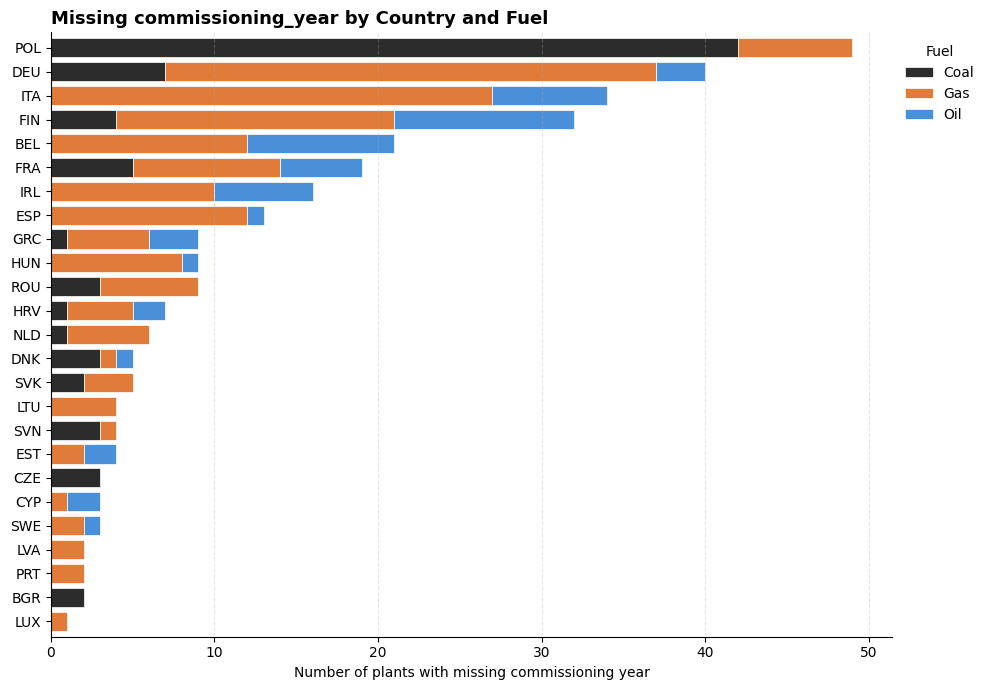

Figure saved to: ../../outputs/figures/missing_commissioning_year_by_country_fuel.png


,primary_fuel,total,missing,missing_pct_in_fuel,missing_pct_of_total
0,Coal,279,77,27.6,25.5
1,Gas,439,171,39.0,56.6
2,Oil,106,54,50.9,17.9


In [6]:
colors = {'Coal': '#2c2c2c', 'Gas': '#e07b39', 'Oil': '#4a90d9'}

missing_by_country = (
    df_eu.groupby(['country', 'primary_fuel'])
    .agg(
        total=('gppd_idnr', 'count'),
        missing=('commissioning_year', lambda x: x.isna().sum())
    )
    .assign(missing_pct=lambda x: (x['missing'] / x['total'] * 100).round(1))
    .query('missing > 0')
    .reset_index()
)

pivot = missing_by_country.pivot_table(
    index='country', columns='primary_fuel', values='missing', fill_value=0
)
pivot['total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('total', ascending=True).drop(columns='total')

color_list = [colors.get(c, '#aaaaaa') for c in pivot.columns]

fig, ax = plt.subplots(figsize=(10, 7))
pivot.plot(kind='barh', stacked=True, ax=ax, color=color_list,
           width=0.8, edgecolor='white', linewidth=0.5)

ax.set_title('Missing commissioning_year by Country and Fuel',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Number of plants with missing commissioning year')
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.legend(title='Fuel', bbox_to_anchor=(1, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

save_path = '../../outputs/figures/missing_commissioning_year_by_country_fuel.png'
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {save_path}")

# Summary by fuel type
missing_summary = (
    df_eu.groupby('primary_fuel')
    .agg(
        total=('gppd_idnr', 'count'),
        missing=('commissioning_year', lambda x: x.isna().sum())
    )
    .assign(missing_pct_in_fuel=lambda x: (x['missing'] / x['total'] * 100).round(1))
    .assign(missing_pct_of_total=lambda x: (x['missing'] / x['missing'].sum() * 100).round(1))
    .reset_index()
)
display(missing_summary)

### 5. Fuel label harmonisation

We normalise `primary_fuel` to three clean labels: `coal`, `gas`, `oil`. The GPPD encodes all solid fossil fuels under `'Coal'` — no further subdivision is applied.

In [7]:
fuel_map = {'Coal': 'coal', 'Gas': 'gas', 'Oil': 'oil'}
df_eu['fuel'] = df_eu['primary_fuel'].map(fuel_map)

print("Fuel label distribution after harmonisation:")
display(
    df_eu.groupby('fuel').agg(
        plants=('gppd_idnr', 'count'),
        capacity_mw=('capacity_mw', 'sum')
    ).rename(columns={'capacity_mw': 'capacity (MW)'})
)

Fuel label distribution after harmonisation:


,plants,capacity (MW)
fuel,,
coal,279,"143,256.2"
gas,439,"142,168.5"
oil,106,"28,932.0"


### 6. Descriptive statistics — capacity by country and fuel

Country-level capacity breakdown. This reveals the geographic concentration of exposure: <br> 
Germany and Poland together account for the majority of coal capacity in the EU, making them the dominant drivers of stranding results.

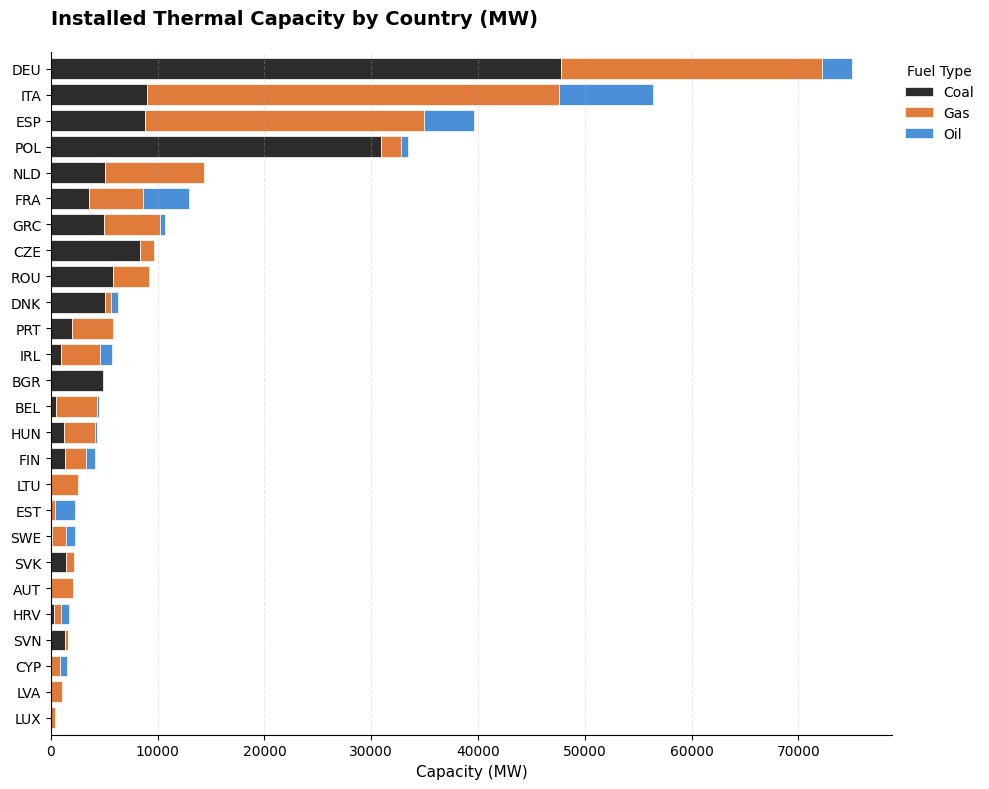

In [8]:
summary = (
    df_eu.groupby(['country', 'fuel'])['capacity_mw']
    .sum()
    .unstack(fill_value=0)
)

summary['total'] = summary.sum(axis=1)
summary = summary.sort_values('total', ascending=True)

colors = {
    'coal': '#2c2c2c',
    'gas': '#e07b39',
    'oil': '#4a90d9'
}

plot_df = summary.drop(columns='total')
color_list = [colors.get(c) for c in plot_df.columns]

fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

plot_df.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=color_list,
    width=0.8,
    edgecolor='white',
    linewidth=0.5
)

ax.set_title('Installed Thermal Capacity by Country (MW)', fontsize=14, fontweight='bold', loc='left', pad=20)
ax.set_xlabel('Capacity (MW)', fontsize=11)
ax.set_ylabel('')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.3)

ax.legend(
    [c.capitalize() for c in plot_df.columns],
    title='Fuel Type',
    bbox_to_anchor=(1, 1),
    loc='upper left',
    frameon=False
)

plt.tight_layout()
plt.savefig('../../outputs/figures/eu_fossil_capacity_by_fuel.png', dpi=150, bbox_inches='tight')
plt.show()


### 7. Figure 1 — EU fossil fuel power plants map

Each plant is plotted at its geolocated coordinates. Marker size is proportional to installed capacity (MW). Colour encodes fuel type.

**Shapefile required (one-time download):**  
Natural Earth 110m Admin-0 Countries — https://www.naturalearthdata.com/downloads/110m-cultural-vectors/  
Extract to `data/raw/ne_110m_admin_0_countries/`

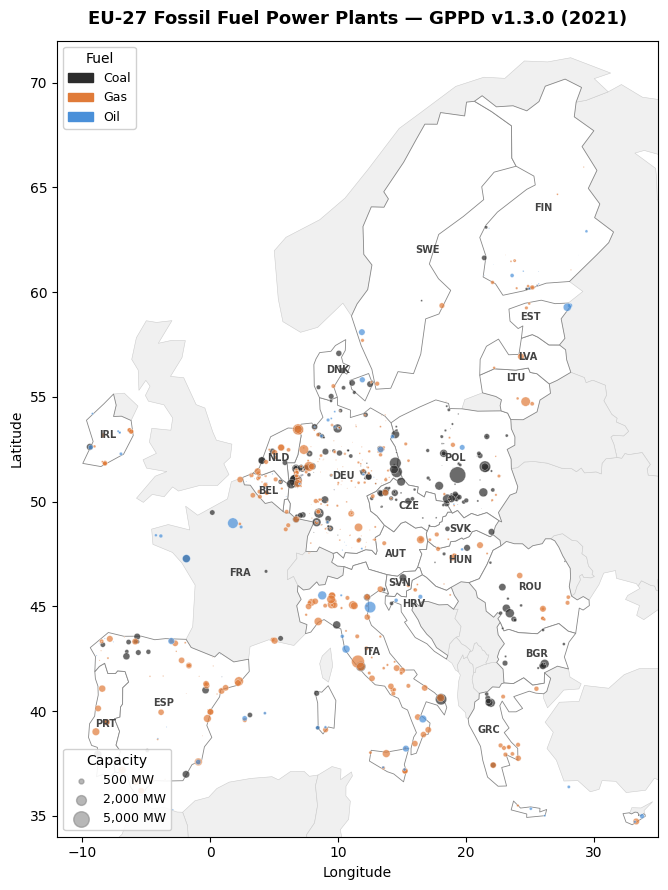

In [9]:
EU27 = [
    'AUT','BEL','BGR','HRV','CYP','CZE','DNK','EST','FIN','FRA','DEU','GRC','HUN',
    'IRL','ITA','LVA','LTU','LUX','MLT','NLD','POL','PRT','ROU','SVK','SVN','ESP','SWE'
]

fuel_colors = {'coal': '#2c2c2c', 'gas': '#e07b39', 'oil': '#4a90d9'}

country_labels = {
    'DEU': (10.4, 51.2), 'POL': (19.1, 52.1), 'ITA': (12.6, 42.8),
    'ESP': (-3.7, 40.4), 'FRA': (2.3, 46.6),  'CZE': (15.5, 49.8),
    'ROU': (25.0, 45.9), 'BGR': (25.5, 42.7), 'NLD': (5.3, 52.1),
    'GRC': (21.8, 39.1), 'HUN': (19.5, 47.2), 'DNK': (10.0, 56.3),
    'FIN': (26.0, 64.0), 'SWE': (17.0, 62.0), 'PRT': (-8.2, 39.4),
    'BEL': (4.5, 50.5),  'AUT': (14.5, 47.5), 'SVK': (19.5, 48.7),
    'SVN': (14.8, 46.1), 'HRV': (15.9, 45.1), 'EST': (25.0, 58.8),
    'LTU': (23.9, 55.9), 'LVA': (24.8, 56.9), 'IRL': (-8.0, 53.2),
}

fig, ax = plt.subplots(figsize=(13, 9))

shapefile_path = '../../data/raw/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp'
has_shapefile = os.path.exists(shapefile_path)

if has_shapefile:
    world = gpd.read_file(shapefile_path)
    eu_shapes = world[world['ISO_A3'].isin(EU27)]
    non_eu    = world[~world['ISO_A3'].isin(EU27)]
    non_eu.clip((-15, 33, 37, 73)).plot(ax=ax, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.4)
    eu_shapes.plot(ax=ax, color='#ffffff', edgecolor='#888888', linewidth=0.6)
else:
    print("Shapefile not found — rendering without country borders.")
    print("Download: naturalearth.com/downloads/110m-cultural-vectors/")
    ax.set_facecolor('#dce9f5')
    ax.grid(True, alpha=0.25, color='white', linewidth=0.8)

for fuel, group in df_eu.groupby('fuel'):
    ax.scatter(
        group['longitude'], group['latitude'],
        s=group['capacity_mw'] / 40,
        c=fuel_colors[fuel], alpha=0.70,
        edgecolors='white', linewidths=0.3,
        zorder=4
    )

for iso, (lon, lat) in country_labels.items():
    ax.text(lon, lat, iso, fontsize=7, color='#444444',
            ha='center', va='center', zorder=5, fontweight='bold')

ax.set_xlim(-12, 35)
ax.set_ylim(34, 72)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.set_title(
    'EU-27 Fossil Fuel Power Plants — GPPD v1.3.0 (2021)',
    fontsize=13, fontweight='bold', pad=12
)

fuel_handles = [mpatches.Patch(color=c, label=f.capitalize()) for f, c in fuel_colors.items()]
size_handles = [ax.scatter([], [], s=mw/40, c='#888888', alpha=0.6, label=f'{mw:,} MW')
                for mw in [500, 2000, 5000]]
leg1 = ax.legend(handles=fuel_handles, title='Fuel', loc='upper left', fontsize=9, framealpha=0.9)
ax.add_artist(leg1)
ax.legend(handles=size_handles, title='Capacity', loc='lower left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('../../outputs/figures/fig1_eu_plants_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save output

We keep only the columns relevant for downstream tasks, reducing file size and avoiding confusion with unused GPPD fields.

In [10]:
cols_to_keep = [
    'gppd_idnr', 'name', 'country', 'country_long',
    'fuel', 'primary_fuel',
    'capacity_mw', 'commissioning_year',
    'latitude', 'longitude',
]

df_out = df_eu[cols_to_keep].reset_index(drop=True)

df_out.to_csv('../../data/processed/gppd_eu_clean.csv', index=False)

print(f"Saved: data/processed/gppd_eu_clean.csv")
print(f"Shape : {df_out.shape[0]:,} plants x {df_out.shape[1]} columns")
print()
print('Final dataset summary:')
display(
    df_out.groupby('fuel').agg(
        plants=('gppd_idnr', 'count'),
        capacity_mw=('capacity_mw', 'sum'),
        commissioning_year_missing=('commissioning_year', lambda x: x.isna().sum())
    ).rename(columns={
        'capacity_mw': 'capacity (MW)',
        'commissioning_year_missing': 'missing comm. year'
    })
)


Saved: data/processed/gppd_eu_clean.csv
Shape : 824 plants x 10 columns

Final dataset summary:


,plants,capacity (MW),missing comm. year
fuel,,,
coal,279,"143,256.2",77
gas,439,"142,168.5",171
oil,106,"28,932.0",54
